## Library imports

In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib

## Data imports 

In [2]:
# Import raw monte carlo results 
MC_results = pd.read_excel(f'MC_results.xlsx',sheet_name=None, header = 0)

list_MRIs = list(MC_results.keys())
list_LCIA_methods = list(MC_results[list_MRIs[0]].columns)
Amount_LCIA_methods = MC_results[list_MRIs[0]].shape[1]
print(list_MRIs)

['19', '27', '39', '59', '92', '149', '249', '427', '753', '1367', '2548', '4879', '9585', '19316', '39909', '84503', '183298', '407160']


In [3]:
# Milepost investigated :
MP_investigated = 'MP45'

# Summary of the discretized hazard curve : 
wind_df = pd.read_excel('Discretized_mp_v4.xlsx',header = [0,1],index_col = 0)
wind_df = wind_df[MP_investigated] # Only show the milepost we're focusing on : 
Discrete_hazard_exceedances = wind_df['delta_lambda'].to_numpy()
display(wind_df)

,Midpoint MRI,3 Second Gust Midpoint Wind speed (miles per hr),delta_lambda
0,19,56.380946,0.017162
1,27,65.497865,0.013585
2,39,74.614783,0.010214
3,59,83.731702,0.007331
4,92,92.848621,0.005043
5,149,101.965540,0.003336
6,249,111.082459,0.002127
7,427,120.199378,0.001310
8,753,129.316297,0.000781
9,1367,138.433216,0.000451


In [4]:
MRI_lambdas = {}
for row in wind_df.iterrows(): 
    MRI_lambdas[str(int(row[1]['Midpoint MRI']))] = row[1]['delta_lambda']

## Results weighting & condensing

#### Format MC results to a dataframe

In [5]:
MC_df = {}

for method in list_LCIA_methods : # For each LCIA method : 
    method_df = pd.DataFrame()     
    for i, sim in enumerate(MC_results.keys()) : # Loop through all MRIs :         
        method_df[sim] = MC_results[str(sim)][method]

    # Data clean up : make sure all MRIs have the same amount of samples available    
    method_df = method_df.dropna(axis = 0 ) 
    
    
    # Data clean up : ensure samples are sensibly acceptable (LCA MC simulations can sometimes go out of hands) : 
    initial_size = method_df.shape
        
    # Clear odd samples : 
    # Some results randomly return below 0 and must be discarded:    
    method_df = method_df[method_df.any(axis =1)>0]

        # Warn if several results are removed : 
    if (initial_size[0] - method_df.shape[0]) > 50 : 
        print(results_array.shape)
        print(f'Warning - {initial_size[0]-results_array.shape[0]} simulations cleared in MRI {sim} sample!')
    
    MC_df[method] = method_df
       
# Display a sample of a dataframe : 
print(list_LCIA_methods[0])
display(MC_df[list_LCIA_methods[0]])

('IPCC 2021', 'climate change', 'global warming potential (GWP100)')


,19,27,39,59,92,149,249,427,753,1367,2548,4879,9585,19316,39909,84503,183298,407160
0,82.474385,203.290851,634.927050,490.722904,1335.838470,1217.185122,1887.035269,10043.789187,13077.271424,22911.626647,28388.456888,100920.649095,73272.630435,127029.140862,9.806713e+06,1.165323e+07,1.311505e+07,1.232298e+07
1,0.000000,0.000000,194.589624,283.655509,798.381970,1449.807082,2701.125403,3724.886500,26855.510560,15210.141720,24407.756340,96406.127275,145230.120246,121234.453073,2.487126e+06,1.223123e+07,1.412491e+07,1.266121e+07
2,0.000000,196.820057,234.961535,696.800291,1527.543904,2245.955143,2949.109004,5446.061503,5843.741992,20277.665780,17811.683934,65288.586680,112609.475542,134193.681975,1.065508e+06,1.355800e+07,1.274588e+07,1.216477e+07
3,0.000000,0.000000,425.207892,768.856845,1077.428209,1491.082374,3531.004472,3866.807729,6733.198763,23796.975053,33684.151754,143861.206831,67800.801391,178981.070932,1.220578e+07,1.498951e+05,1.218283e+07,1.270436e+07
4,0.000000,95.170841,85.201740,790.065566,1060.393204,878.234496,2394.341954,10258.865786,4708.966525,16736.068587,36405.131993,52273.582887,15570.250184,175611.176984,1.678860e+06,2.155752e+05,1.229706e+07,1.157814e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11015,169.561649,0.000000,244.236747,736.259080,1405.140513,2507.372939,2047.492566,9444.546084,31909.283893,9421.991923,37111.398423,56531.973155,81228.285705,174118.264635,1.324887e+07,1.863610e+07,1.219676e+07,1.091773e+07
11016,88.351492,0.000000,172.957025,328.714083,1047.974087,2205.158427,5627.831955,3181.611391,13362.680728,13733.548292,22190.983330,27663.518012,82397.500172,193770.404665,1.410003e+06,1.211773e+07,1.206341e+07,1.317961e+07
11017,94.786277,86.813841,506.848052,411.589173,1357.023784,1479.123778,1963.735738,3994.973934,18178.826313,6271.405752,19528.229054,62084.069863,59145.147892,78218.739102,1.499240e+07,1.424795e+07,1.053658e+07,1.546862e+07
11018,84.367933,0.000000,698.932251,525.480838,1538.808655,2822.260844,2359.613823,4537.343179,6905.869486,18853.451557,31343.585252,62785.178367,68757.871963,103711.409184,1.303229e+07,1.153633e+07,1.186705e+07,1.553171e+07


In [6]:
bin_count = 1000

bins = {}
pmfs = {}


for method in list_LCIA_methods : 
    esf_results = {}
    bin_data = {}
    pmf_results = {}
    
    for MRI in list_MRIs :  

        data = MC_df[method][MRI]
        hist, bin_edges = np.histogram(data,bins = bin_count, density = True)
        pmf = hist*np.diff(bin_edges)  

        # Bin midpoints 
        bin_midpts = (bin_edges[1:] + bin_edges[:-1]) / 2

        # CDF
        cdf = np.cumsum(pmf)

        # Survival function :
        esf = 1 - cdf

        # Store results : 
        esf_results[MRI] = esf
        bin_data[MRI] = bin_midpts
        pmf_results[MRI] = pmf
    bins[method] = bin_data
    pmfs[method] = pmf_results

In [ ]:
method_EAL = {}
method_EAL_contrib = {}
method_exceedances = {}

for method in list_LCIA_methods:
    
    # Initialize variables :
    EAL = 0
    weighted_prob_concats = np.array([])
    x_concats = np.array([])
    EAL_contrib = {}
    
    
    all_intensities_df = pd.DataFrame()

    # Start iterating for results 
    for MRI in list_MRIs : 
        

        # Recover probability masses & survival function values :
        pmf = pmfs[method][MRI]        
        x = bins[method][MRI]

        # Weight the results according intensity delta MAFE: 
        pmf2 = pmf*MRI_lambdas[MRI]
        uniques_to_check = np.unique(x)
        
        # Keep track of the MRI's contribution relative to final EAL : 
        EAL_contrib[MRI] = (pmf2*uniques_to_check).sum()
        
        # Group with the others : 
        x_concats = np.concatenate((x_concats,x))
        weighted_prob_concats = np.concatenate((weighted_prob_concats,pmf2))   


        # Intermediate contributions :
        intensity_uniques,intensity_inv = np.unique(x_concats, return_inverse=True)
        intensity_sums = np.zeros(len(intensity_uniques),dtype=weighted_prob_concats.dtype)
        np.add.at(intensity_sums,intensity_inv,weighted_prob_concats)

        intensity_df = pd.DataFrame(index = intensity_uniques)
        intensity_df[MRI] = intensity_sums

        all_intensities_df = pd.concat([all_intensities_df,intensity_df])


    # Find individual intensity contributions : 
    all_intensities_df = all_intensities_df.fillna(0)
    all_intensities_df = all_intensities_df.sort_index().cumsum()
        # Get rid of duplicates from concatenation : 
    all_intensities_df = all_intensities_df.loc[~all_intensities_df.index.duplicated(keep='last'), :]
        # Set aside a copy of the first intensity column 
    column1 = all_intensities_df.iloc[:,0]
        # Deaggregate contributions :
    all_intensities_df = all_intensities_df.diff(axis = 1)
        # Reset intensity 1 to original value
    all_intensities_df[list_MRIs[0]] = column1
        # Numpy array : invert contributions 
    all_intensities_array = all_intensities_df.to_numpy()
    base_array = np.tile(all_intensities_array[-1,:],(all_intensities_array.shape[0],1))
    all_intensities_inv_cumul_sum = base_array-all_intensities_array
    all_intensities_inv_cumul_sum = np.vstack((all_intensities_array[-1,:],all_intensities_inv_cumul_sum[:-1,:]))
        # Bring back to a nice complete dataframe :
    contrib_df = pd.DataFrame(all_intensities_inv_cumul_sum,columns = all_intensities_df.columns, index = all_intensities_df.index)

    # Find cumulative contribution to plot first intensity as top value, rarest as bottom value : 
    contrib_df = contrib_df.iloc[:, ::-1].cumsum(axis = 1)
    contrib_df = contrib_df.iloc[:,::-1] # Put the columns back to an ascending order

    # Build the envelope curve :
    # Find uniques, and coordinate :
    u,inv = np.unique(x_concats, return_inverse= True)
    # Find the true pmf for each unique value
    sums = np.zeros(len(u),dtype=weighted_prob_concats.dtype)
    np.add.at(sums,inv,weighted_prob_concats)    

    df = pd.DataFrame(index = u)
    df['PMF'] = sums
    cumul_sum = np.cumsum(sums)

    inverted_cumul_sum = cumul_sum[-1] - cumul_sum
    inverted_cumul_sum = np.insert(inverted_cumul_sum,0,cumul_sum[-1])
    df['Prob_exceed'] = inverted_cumul_sum[:-1]

    # Assemble final dataframe : 
    df = pd.concat([df, contrib_df], axis=1)
    method_exceedances[method] = df
    
    EAL = (u*sums).sum()
    method_EAL[method] = EAL
    method_EAL_contrib[method] = pd.DataFrame.from_dict(EAL_contrib,orient = 'index', columns = ['indiv contrib'])
    
print(method_EAL)

In [9]:
print('Assuming a 50 years horizon')
for k, v in method_EAL.items() : 
    print(k,v*50)

Assuming a 50 years horizon
('IPCC 2021', 'climate change', 'global warming potential (GWP100)') 19139.92205
('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality') 0.00012272907229752712
('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health') 0.15930498541343563
('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources') 2178.317547011988
('IMPACT World+ Damage 2.0.1', 'Ecosystem quality', 'Total ecosystem quality') 33989.6795
('IMPACT World+ Damage 2.0.1', 'Human health', 'Total human health') 0.2553


### Graph loss curves

In [13]:
# Ensure the order is the same as other figures
Plot_order = {
    0:'GWP',
    1:'Ecosystem',
    2:'Human'
}

Method_labels = {
    'GWP':'IPCC 2021 - GWP100',
    'Ecosystem':'IW+ (2.0.1) Ecosystem Quality',
    'Human': 'IW+ (2.0.1) Human Health'
}


Two_line_Method_labels = {
    'GWP':'IPCC 2021 \n GWP100',
    'Ecosystem':'IW+ (2.0.1) \n Ecosystem Quality',
    'Human': 'IW+ (2.0.1) \n Human Health'   
 
}


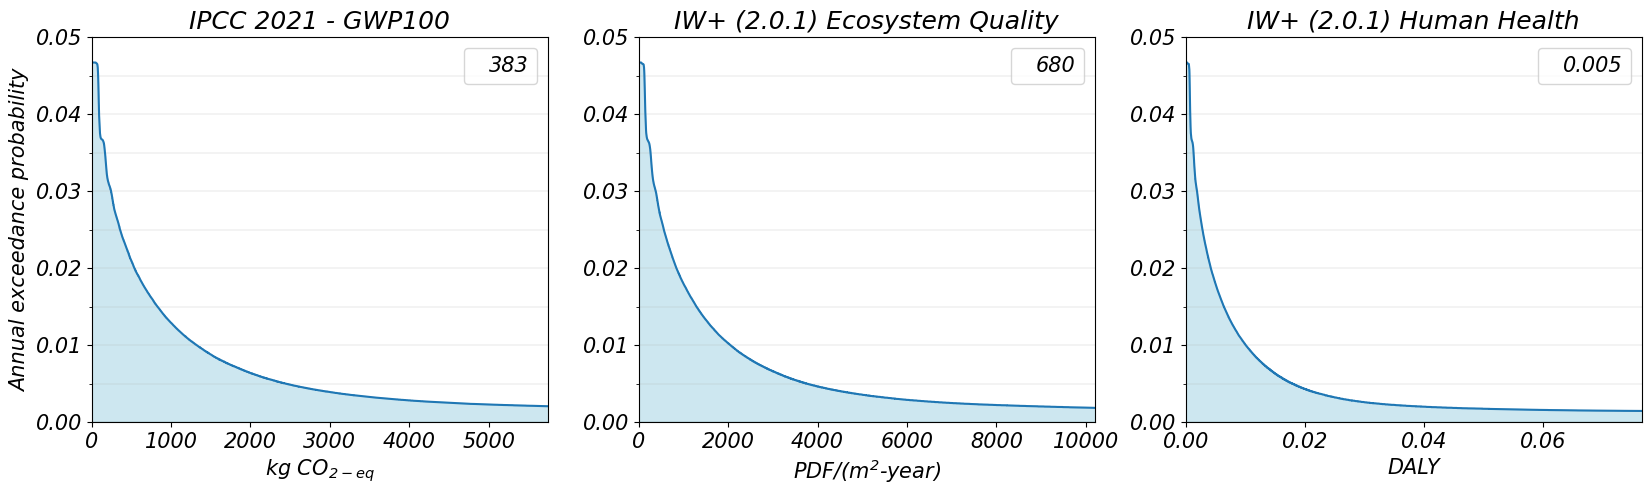

In [16]:
# Line only or filled?
fill_graph = True
show_EAL = True

# Select the desired LCIA methods : 
selected_LCIA_2display = [0,4,5,]
units = ['kg CO$_{2-eq}$','PDF/(m$^2$-year)','DALY' ]

#-------------- Make a nice figure out of it :
# Adjust the font size :
# creating a dictionary
font = {'size': 15}
# using rc function
plt.rc('font', **font)

# Visual outputs
fig, axs = plt.subplots(1, len(selected_LCIA_2display), figsize=(20, 1*5))

# Fill in the figure with data : 
for j,LCIA_method_ID in enumerate(selected_LCIA_2display): 

    method = list_LCIA_methods[LCIA_method_ID]
    selected_EAL = method_EAL[method]
    
    exceedance_df = method_exceedances[method]    
    xi = exceedance_df.index
    yi = exceedance_df['Prob_exceed'].array

    # Add a value at origin : 
    xi = np.insert(xi,0,0)
    yi = np.insert(yi,0,yi[0])    
    
    axs[j].set_xlim(0,selected_EAL*15)
    axs[j].set_ylim(0,0.05)
    
    # Plots
    label = Method_labels[Plot_order[j]]
    axs[j].set_title(f'{label}')   
    
    
    if LCIA_method_ID == 0 :
        #EAL_label = f'{int(selected_EAL//10*10):}'
        EAL_label = format(selected_EAL, '.0f')
    else : 
        if selected_EAL > 1 : 
            EAL_label = format(selected_EAL, '.0f')
        else : 
            EAL_label = format(selected_EAL,'.3f')
    
    
    
    if LCIA_method_ID == 0 : 
        axs[j].plot(xi,yi,label = EAL_label)
    else :
        axs[j].plot(xi,yi,label = EAL_label)
    if fill_graph == True : 
        axs[j].fill_between(xi, yi, interpolate=True, color='lightblue',alpha = 0.6)
    if show_EAL == True : 
        axs[j].legend(handlelength=0)
    
    axs[0].set_ylabel('Annual exceedance probability')
    axs[j].set_xlabel(units[j])
    axs[j].grid(axis='y', linewidth = 0.2) 
    
    axs[j].locator_params(axis='y', nbins=6)
    axs[j].minorticks_on()
    axs[j].grid(visible=True, which='minor', linestyle='-',linewidth = 0.2, axis = 'y') 
    axs[j].grid(axis='y', linewidth = 0.2)    
    axs[j].tick_params(axis='x', which='minor', bottom=False)    
    axs[j].yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
plt.show() 
fig.savefig('component_EAL.png', format='png', dpi=300)